#Credit Risk Prediction System

In [ ]:
#IMPORT ALL THE NECESSARY LIBRARIES

#Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# import model
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler



In [ ]:
#LOAD DATASET

#load dataset
df = pd.read_excel('/content/default of credit card clients.xls', header=1)
df =df.rename(columns={'unnamed:0': 'ID'})
df =df.set_index('ID')

#Display first five rows
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
#BASIC INFORMATION

df.info()  # Info
df.describe()  # Statistical summary


<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_AMT4  

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [ ]:
#CHECK MISSING VALUES

df.isnull().sum()

,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0
PAY_5,0


In [ ]:
#If misssing value exist

df = df.dropna()  # simple handling

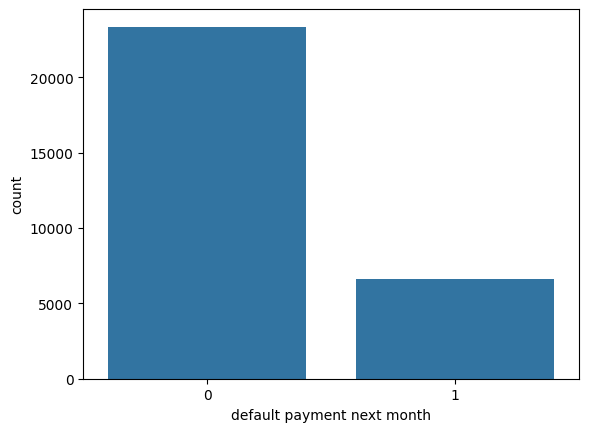

In [ ]:
#check class distribution (imbalance)
#visualization

sns.countplot(x='default payment next month',data=df)
plt.show()

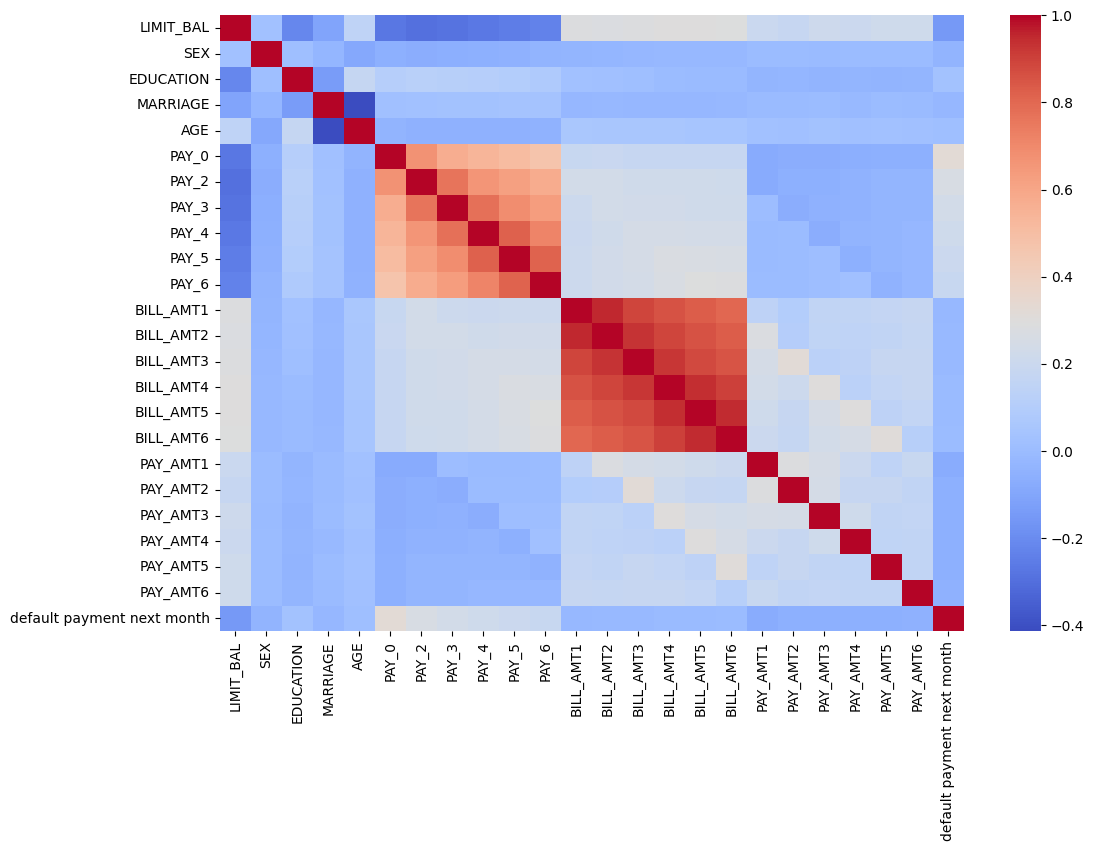

In [ ]:
#correlation heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap ='coolwarm')
plt.show()

#PHASE 2: DATA PREPROCESSING


In [ ]:
# train_test_split(with stratification)

#features and target
x= df.drop('default payment next month', axis=1)
y= df['default payment next month']

# Stratified Split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)
print('train shape', x_train.shape)
print("test shape", x_test.shape)

train shape (24000, 23)
test shape (6000, 23)


In [ ]:
#feature scalling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#PHASE 3: MODEL BUILDING

In [ ]:
from imblearn.over_sampling import SMOTE
import xgboost as xgb

In [ ]:
#Apply smote
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)


In [ ]:
#Feature scaling
scaler = StandardScaler()
x_train_smote = scaler.fit_transform(x_train_smote)
x_test = scaler.transform(x_test)


In [ ]:
#Define models

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier # Added this import

import xgboost as xgb

models = {

    "Logistic Regression (L2)": LogisticRegression(penalty='l2'),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(random_state=42),

    "SVM": SVC(probability=True),

    "Naive Bayes": GaussianNB(),

    "Gradient Boosting": GradientBoostingClassifier(),

    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [ ]:
# train and evaluate models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in models.items():

    model.fit(x_train_smote, y_train_smote)

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, roc])

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:53:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
#comparsion table
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"
])

results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

print(results_df)

                      Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
6         Gradient Boosting  0.795667   0.540693  0.505652  0.522586  0.766687
4                       SVM  0.779167   0.500687  0.549359  0.523895  0.753791
3             Random Forest  0.795500   0.543478  0.470987  0.504643  0.750409
7                   XGBoost  0.801667   0.568159  0.430294  0.489708  0.750187
5               Naive Bayes  0.472833   0.271982  0.825170  0.409116  0.715120
0  Logistic Regression (L2)  0.672333   0.361388  0.627732  0.458700  0.710437
1                       KNN  0.653333   0.343060  0.620196  0.441761  0.684717
2             Decision Tree  0.697667   0.357352  0.459683  0.402109  0.613619


#Phase 4.Hyperparameter Tuning


In [ ]:
#import library
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score



a) Random Forest Tuning


In [ ]:
# Baseline Model
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(x_train_smote, y_train_smote)

y_pred_base = rf_base.predict(x_test)
print("Baseline Random Forest ROC-AUC:",
      roc_auc_score(y_test, rf_base.predict_proba(x_test)[:,1]))

Baseline Random Forest ROC-AUC: 0.7504094857162575


In [ ]:
# Hyperparameter Grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
# GridSearch
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(x_train_smote, y_train_smote)

print("Best RF Parameters:", grid_rf.best_params_)


Best RF Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
# Tuned Model Evaluation
best_rf = grid_rf.best_estimator_

print("Tuned Random Forest ROC-AUC:",
      roc_auc_score(y_test, best_rf.predict_proba(x_test)[:,1]))

Tuned Random Forest ROC-AUC: 0.345599735916586


b)XGBoost Tuning

In [ ]:
from xgboost import XGBClassifier


In [ ]:
# Baseline XGBoost
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_base.fit(x_train_smote, y_train_smote)

print("Baseline XGBoost ROC-AUC:",
      roc_auc_score(y_test, xgb_base.predict_proba(x_test)[:,1]))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:13:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Baseline XGBoost ROC-AUC: 0.7501867822510015


In [ ]:
# Parameter Grid
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_xgb.fit(x_train_smote, y_train_smote)

print("Best XGB Parameters:", grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_

print("Tuned XGBoost ROC-AUC:",
      roc_auc_score(y_test, best_xgb.predict_proba(x_test)[:,1]))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:15:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Tuned XGBoost ROC-AUC: 0.7586939417400639


#Phase 5: Bias-Variance Analysis



* Learning Curve



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

model = best_rf   # use best model

train_sizes, train_scores, test_scores = learning_curve(
    model,
    x_train_smote,
    y_train_smote,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Plot Learning Curve
plt.figure()
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("ROC-AUC Score")
plt.title("Learning Curve (Bias-Variance Analysis)")
plt.legend()
plt.show()

NameError: name 'best_rf' is not defined

# 6: Final Model Evaluation

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Random Forest Predictions
rf_pred = best_rf.predict(x_test)
rf_prob = best_rf.predict_proba(x_test)[:,1]

# XGBoost Predictions
xgb_pred = best_xgb.predict(x_test)
xgb_prob = best_xgb.predict_proba(x_test)[:,1]


# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1-Score": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

print(comparison)

           Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Random Forest  0.272333   0.226561  0.948757  0.365776  0.345600
1        XGBoost  0.231000   0.222147  0.990203  0.362883  0.610792


In [ ]:
best_model_name = comparison.loc[
    comparison["ROC-AUC"].idxmax(), "Model"
]

print("Best Model Selected:", best_model_name)

Best Model Selected: XGBoost


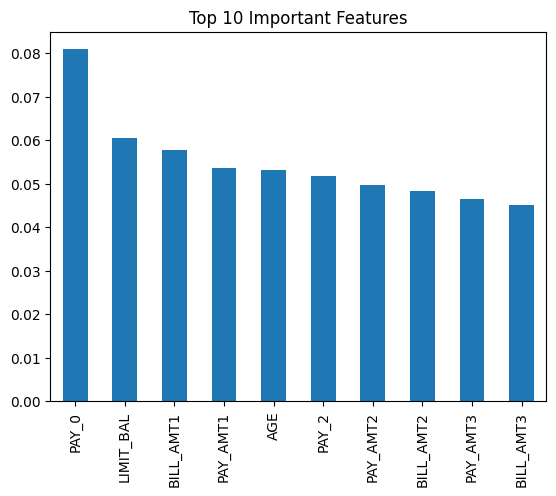

In [ ]:
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=x.columns # Use columns from the original DataFrame 'x'
).sort_values(ascending=False)

plt.figure()
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

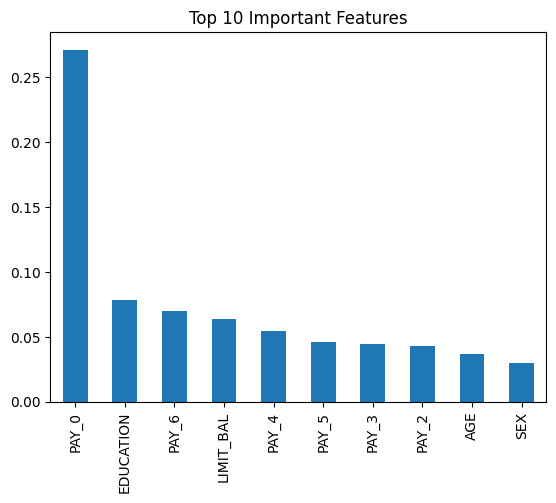

In [ ]:
feature_importance = pd.Series(
    best_xgb.feature_importances_,
    index=x.columns # Use columns from the original DataFrame 'x'
).sort_values(ascending=False)

plt.figure()
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()